# Avaliação do Modelo — Conjunto de Teste

Este notebook avalia os modelos finais treinados no conjunto de dados de teste,
utilizando métricas de classificação e matrizes de confusão.

## Preparação do Ambiente

Nesta seção:
- adicionamos `src/` ao `sys.path` para importar funções do projeto
- importamos utilitários de visualização e métricas de avaliação

A avaliação será feita no conjunto de teste retornado pelo pipeline de treino.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve() / "src"))


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from preprocessing import preprocess_data
from train import train_models


## Treinamento e obtenção do conjunto de teste

Executamos a rotina de treino para:
- treinar os modelos candidatos
- obter um dicionário de métricas (`results`) para comparação
- recuperar os objetos de modelo treinados (`models`)
- receber o conjunto de teste (`X_test`, `y_test`) para avaliação final


In [2]:
results, models, (X_test, y_test) = train_models()


Experimento 1 (sgd): pop=20, gens=20, mutation=0.1
[sgd] Geração 0 - Melhor fitness: 0.7849
[sgd] Geração 1 - Melhor fitness: 0.7849
[sgd] Geração 2 - Melhor fitness: 0.7849
[sgd] Geração 3 - Melhor fitness: 0.7849
[sgd] Geração 4 - Melhor fitness: 0.7849
[sgd] Geração 5 - Melhor fitness: 0.7849
[sgd] Geração 6 - Melhor fitness: 0.7849
[sgd] Geração 7 - Melhor fitness: 0.7849
[sgd] Geração 8 - Melhor fitness: 0.7849
[sgd] Geração 9 - Melhor fitness: 0.7849
[sgd] Geração 10 - Melhor fitness: 0.7849
[sgd] Geração 11 - Melhor fitness: 0.7849
[sgd] Geração 12 - Melhor fitness: 0.7849
[sgd] Geração 13 - Melhor fitness: 0.7849
[sgd] Geração 14 - Melhor fitness: 0.7849
[sgd] Geração 15 - Melhor fitness: 0.7849
[sgd] Geração 16 - Melhor fitness: 0.7849
[sgd] Geração 17 - Melhor fitness: 0.7849
[sgd] Geração 18 - Melhor fitness: 0.7849
[sgd] Geração 19 - Melhor fitness: 0.7849

Experimento 2 (sgd): pop=30, gens=25, mutation=0.2
[sgd] Geração 0 - Melhor fitness: 0.7514
[sgd] Geração 1 - Melhor 

## Seleção do melhor modelo

Aqui escolhemos o modelo com base em **recall**.

Motivação: em um cenário de diagnóstico, falsos negativos (predizer “não diabético” quando é diabético) podem ser mais críticos; portanto, priorizamos capturar o máximo possível dos casos positivos.


In [3]:
best_model_name = max(
    results,
    key=lambda m: results[m]["recall"]
)

best_model = models[best_model_name]

print(f"Best model based on recall: {best_model_name}")


Best model based on recall: SGD Classifier (Genetic Algorithm - Best of 3)


## Relatório de classificação

Geramos as predições no conjunto de teste e calculamos métricas por classe:
- precisão (precision)
- revocação (recall)
- F1-score

O `classification_report` ajuda a enxergar o trade-off entre capturar positivos (recall) e reduzir falsos alarmes (precision).


In [4]:
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83        75
           1       0.67      0.78      0.72        41

    accuracy                           0.78       116
   macro avg       0.77      0.78      0.77       116
weighted avg       0.80      0.78      0.79       116



## Matriz de confusão

A matriz de confusão detalha os acertos/erros:
- **TP** (true positives): diabéticos corretamente identificados
- **FN** (false negatives): diabéticos perdidos (ponto mais crítico aqui)
- **FP** (false positives): alarmes falsos
- **TN** (true negatives): não-diabéticos corretamente identificados

O heatmap facilita visualizar rapidamente onde o modelo mais erra.


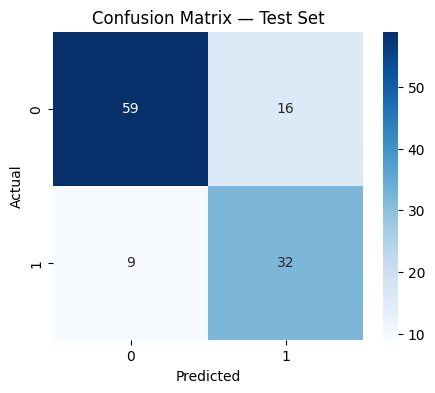

In [5]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set")
plt.show()

## Avaliação no Conjunto de Teste

O modelo selecionado demonstrou um bom desempenho de generalização no
conjunto de dados de teste. A matriz de confusão indica que o modelo
minimiza os falsos negativos, o que é um aspecto crítico em cenários de
diagnóstico médico, como a detecção de diabetes.
